In [1]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator
from scipy.constants import c, h, N_A
from scipy.special import gammainc, gamma



In [ ]:
# ---- Define the integrand ----
def integrand(theta, alpha, beta, m):
    return gammainc(1/m, 4*( (alpha**2+beta**2) * np.cos(theta)**2 - alpha**2)**m)

# ---- Full expression ----
def theta_R(alpha, beta):
    return np.arctan(beta / alpha)

def xi(alpha, beta, m):
    if alpha == 0:
        return 0.0  # avoid division issues / trivial case

    theta_r = theta_R(alpha, beta)

    if m == np.inf:
        d = (alpha**2 - beta**2)/2
        if beta < 1:
            return 2*(-1*d*theta_r + alpha*beta/2)/np.pi
        else:
            return 2*(-1*d*theta_r + alpha*beta/2 + (1+d)*np.arctan(np.sqrt((beta**2-1)/(alpha**2+1)))-np.sqrt((alpha**2+1)*(beta**2-1))/2)/np.pi

    else:

        integral, _ = quad(
            integrand,
            0.0,
            theta_r,
            args=(alpha, beta, m),
            limit=2000
        )

        return 2/np.pi*integral

In [ ]:
type([])

list

In [ ]:
# ---- Plot ----
def plot_xi(A, B, xis, alpha_constants=1, R_constants=5, m=1, beta_half=True, wl=930, n=1.36):
    if type(alpha_constants) != list:
        alpha_constants = [alpha_constants]

    if type(R_constants) != list:
        alpha_constants = [alpha_constants]

    if m == np.inf:
        function_title = r'$\xi_{m\rightarrow\infty}$'
    else:
        function_title = fr'$\xi_{{{m}}}$'

    fig, axs = plt.subplots(1, 3, figsize=(21, 6))
    plt.suptitle(fr'Numerical evaluation of {function_title}$(\alpha,\,\beta)$')
    im = axs[0].contourf(A, B, xis, levels=np.linspace(0, 1, 51))
    axs[0].set_xlabel(r'$\alpha$')
    axs[0].set_ylabel(r'$\beta$')
    
    divider = make_axes_locatable(axs[0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)

    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    
    if beta_half:
        beta_halves = B[np.argmin(np.abs(xis-1/2), axis=0)]
        axs[0].plot(A[0,:], beta_halves, c='k')

    axs[1].set_ylabel(fr'{function_title}$(\alpha,\,\beta)$')
    axs[1].set_xlabel(r'$\beta$')
    axs[1].set_ylim(0, 1)
    axs[1].set_xlim(np.min(B), np.max(B))
    axs[1].grid(True)

    axs[2].sharey(axs[1])
    axs[2].set_xlabel(r'$\alpha$')
    axs[2].set_xlim(np.min(A), np.max(A))
    axs[2].grid(True)

    for alpha_constant in alpha_constants:
        i1 = np.argmin(np.abs(A[0,:]-alpha_constant))
        xis_alpha_constant = xis[:,i1]
        axs[0].vlines(alpha_constant, np.min(A), np.max(A), linestyle='--', color='r')
        axs[1].semilogx(B[:,0], xis_alpha_constant, linestyle='--', color='r')

    for R_constant in R_constants:

        beta_R_constant = np.pi*n*R_constant / (A[0,:]*wl) *1e3
        mask = (
            (beta_R_constant >= B.min()) &
            (beta_R_constant <= B.max())
        )

        alpha_R_constant = A[0,:][mask]
        beta_R_constant = beta_R_constant[mask]
        interpolate = RegularGridInterpolator((A[0,:], B[:,0]), xis)
        xis_R_constant = interpolate(np.column_stack((beta_R_constant, alpha_R_constant)))

        axs[0].plot(alpha_R_constant, beta_R_constant, linestyle=':', c='r')
        axs[2].semilogx(alpha_R_constant, xis_R_constant, linestyle=':', color='r')

    plt.show()

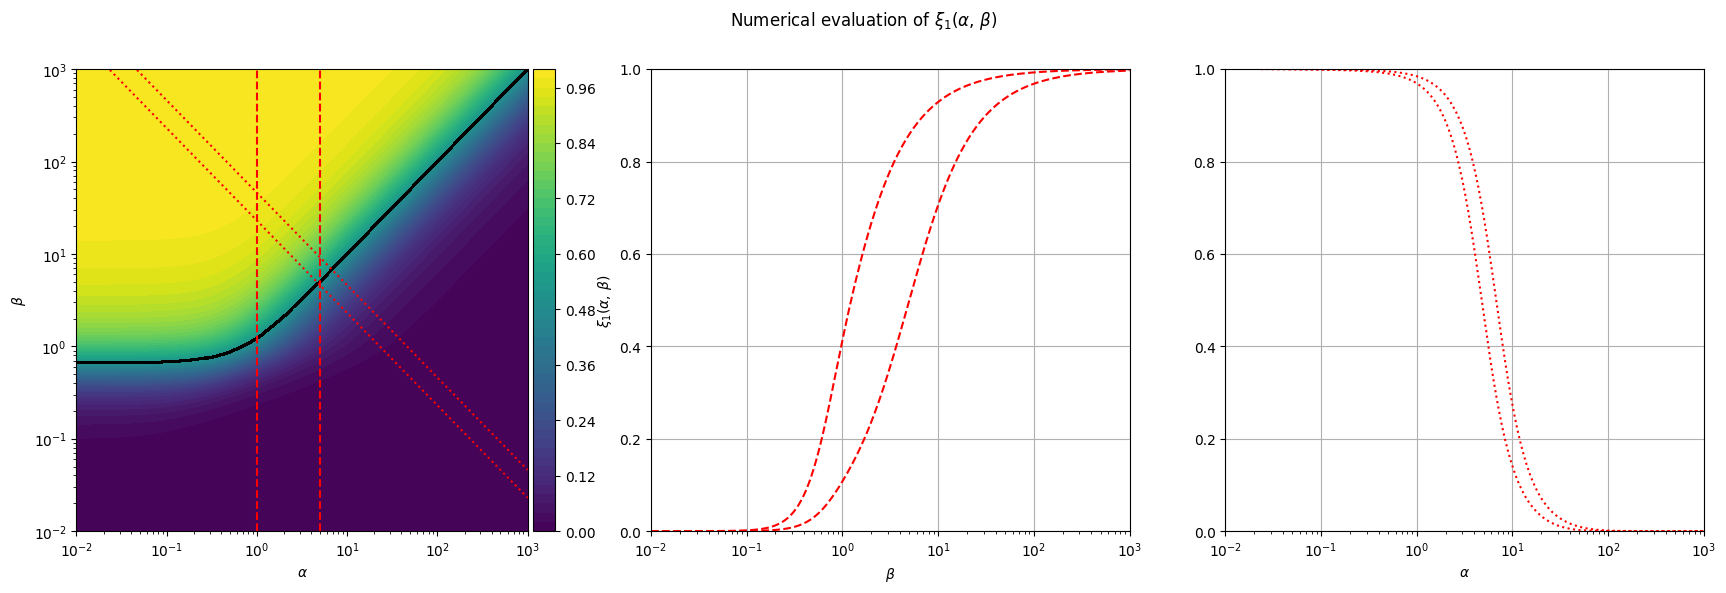

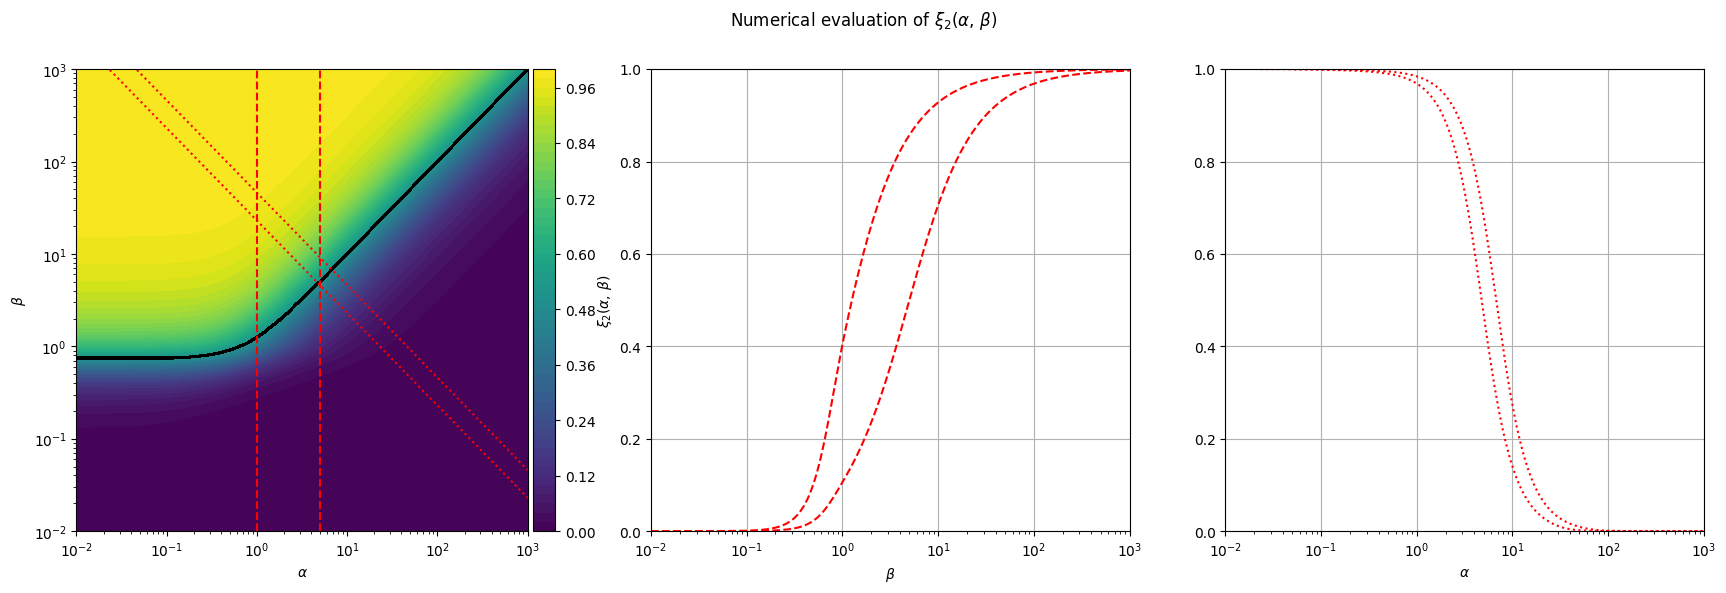

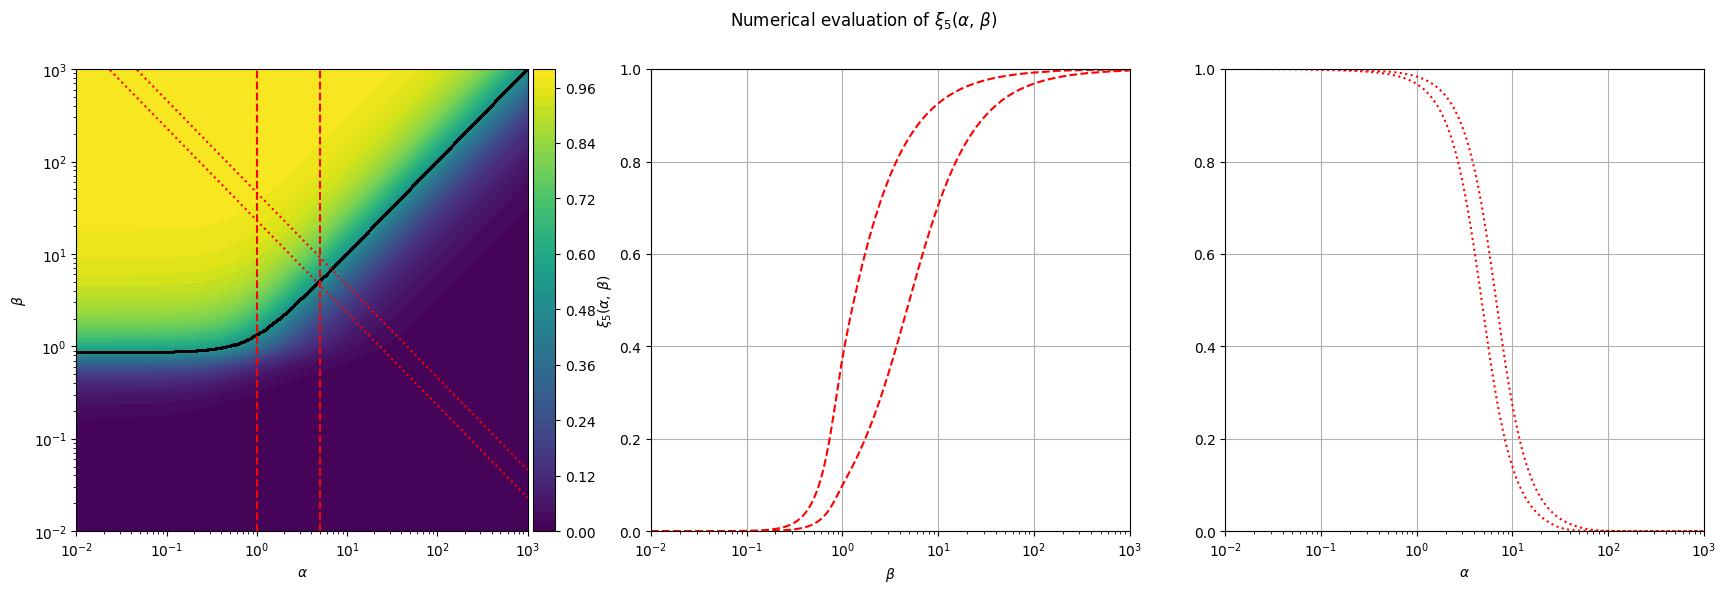

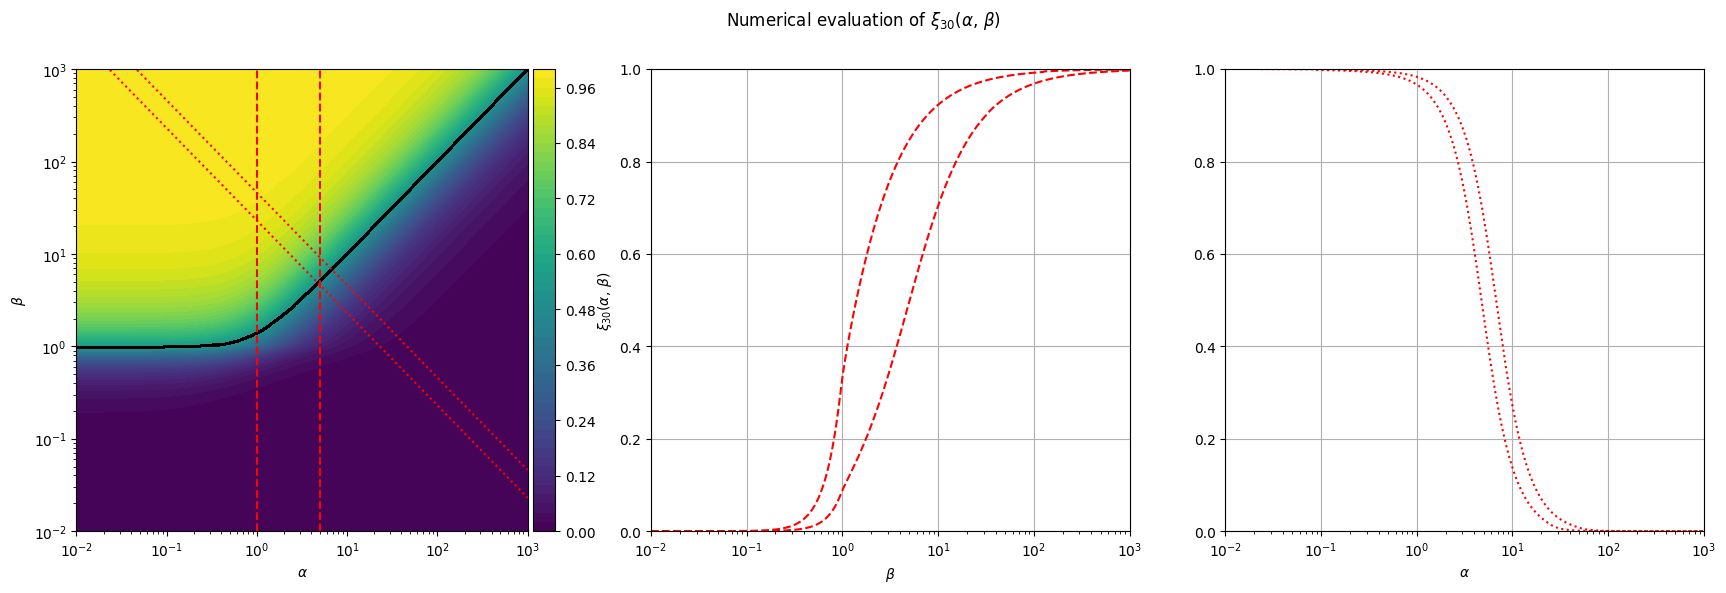

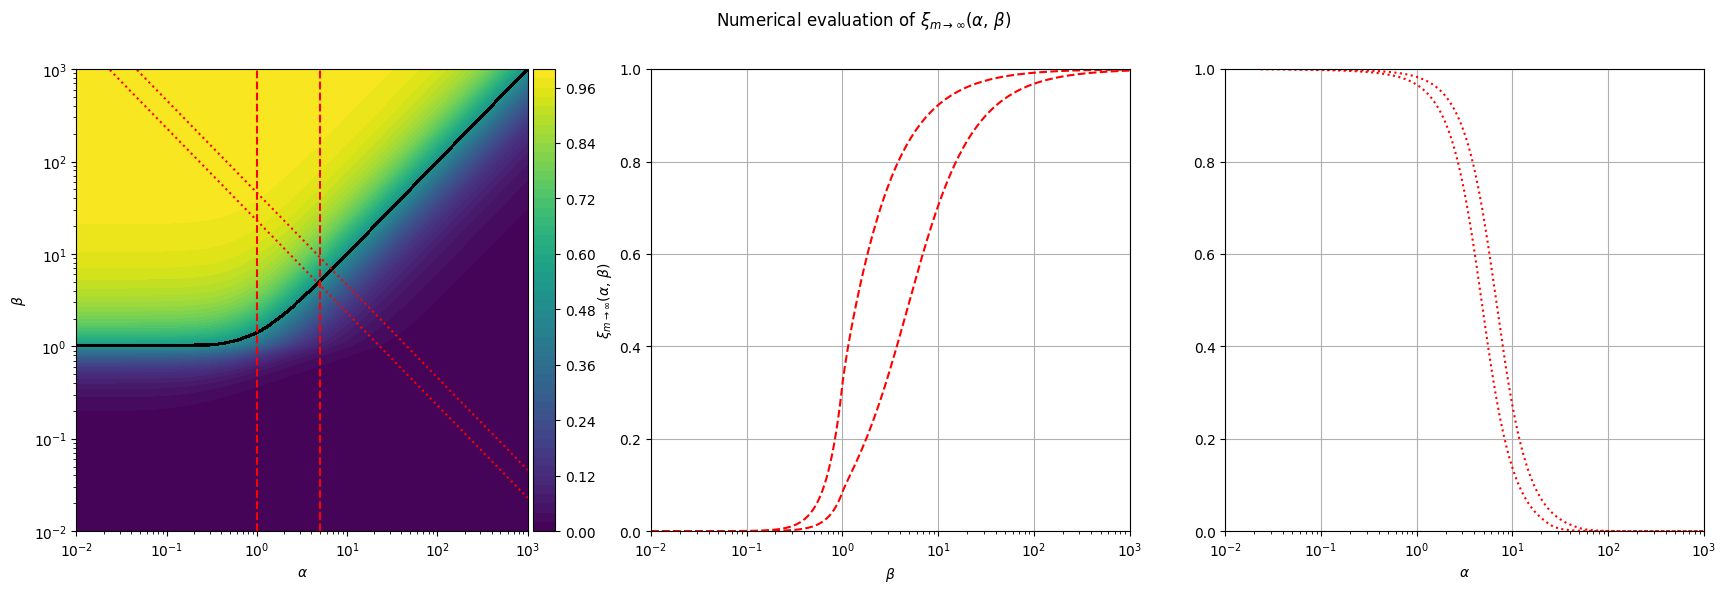

In [ ]:
# ---- Parameter grid ----
alphas = np.geomspace(0.01, 1e3, 500)
betas  = np.geomspace(0.01, 1e3, 500)
ms = [1, 2, 5, 30, np.inf]

A, B = np.meshgrid(alphas, betas)

xis = np.zeros_like(A)

xis_m = np.array([])


for l, m in enumerate(ms):
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            xis[i, j] = xi(A[i, j], B[i, j], m)
    
    plot_xi(A, B, xis, alpha_constants=[1, 5], R_constants=[5, 10], m=m)
    xis_m = np.append(xis_m, xis)

xis_m = xis_m.reshape((len(ms), A.shape[0], A.shape[1]))


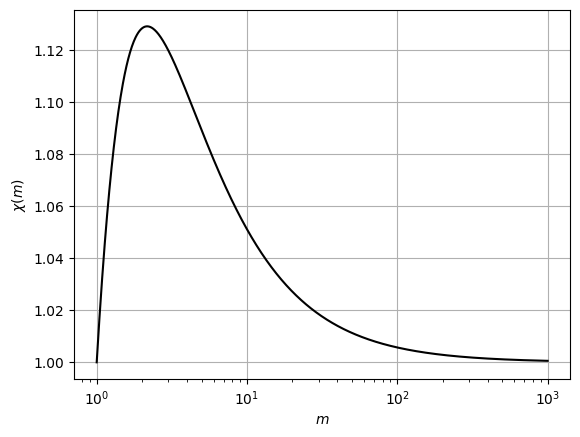

In [ ]:
def chi(m):
    return m/gamma(1/m)

ms = np.geomspace(1, 1000, 1000)
chis = chi(ms)

plt.semilogx(ms, chis, color='k')
plt.xlabel(r'$m$')
plt.ylabel(r'$\chi(m)$')
plt.grid()
plt.show()


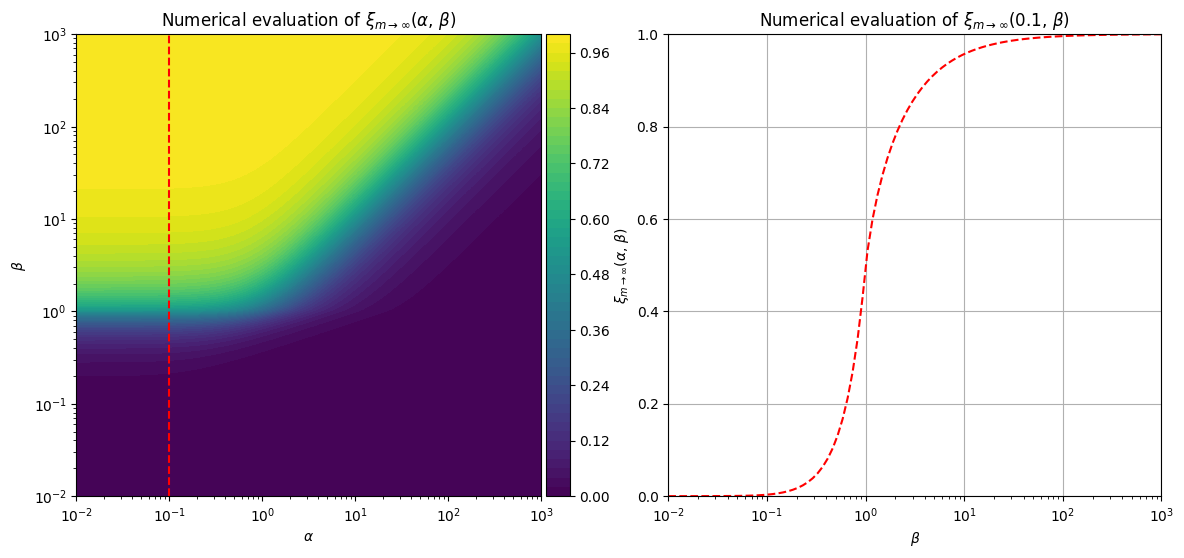

In [ ]:
alphas = np.geomspace(0.01, 1e3, 100)
betas  = np.geomspace(0.01, 1e3, 100)

A, B = np.meshgrid(alphas, betas)

xis = np.zeros_like(A)

m = np.inf

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        xis[i, j] = xi(A[i, j], B[i, j], m)
plot_xi(A, B, xis, alpha_constant=.1, m=m)



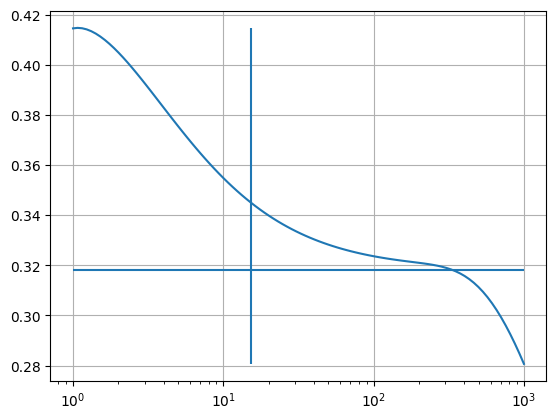

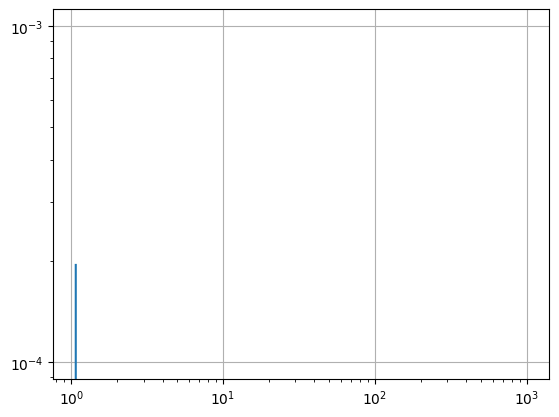

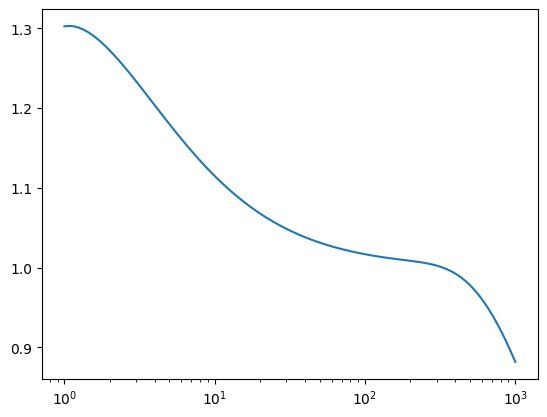

In [ ]:

ms = np.geomspace(1, 1000, 100)
xis = np.zeros_like(ms)


for i, m in enumerate(ms):
    xis[i] = xi(1, 1, m)

    
plt.semilogx(ms, xis)


plt.hlines(1/np.pi, np.min(ms), np.max(ms))
plt.vlines(ms[39], np.min(xis), np.max(xis))
plt.grid()
plt.show()
plt.plot(ms[1:], np.diff(xis))
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.show()
plt.semilogx(ms, xis/xi(1, 1, np.inf))
plt.show()

In [ ]:
def N_det_spot(P = 2,
               C = 2e-6*N_A,  
               wl = 930e-9,
               Phi = 0.7,
               eta = 0.6,
               eta_NA = 0.4,
               sigma = 50e-58,
               f_p = 80e6,
               tau_p = 100e-15,
               chi = 1,
               xi = 1,
               n = 1.36,
               N_ROI = 50):
    return (np.pi*n*wl*Phi*sigma*xi*chi*eta**2*eta_NA*P**2*C) / (2*h**2*c**2*f_p*tau_p*N_ROI**2)

N_det_spot(xi=xi(1, 23, 1), N_ROI = 25)/3.7e3/10

640.4772381952617

In [ ]:
xi(1, 5e-6*np.pi*1.36/(930e-9), 1)

0.9691660719207067

In [ ]:
def EFF(Phi = 0.7,
               eta = 0.6,
               eta_NA = 0.4,
               chi = 1,
               xi = 1):
    return Phi*xi*chi*eta**2*eta_NA

EFF()


0.1008

In [ ]:
def kappa_B(Ca, B_tot, K_d):
    return K_d * Ca * B_tot / (K_d + Ca)**2

def c(Ca, B_tot, kappa_B, kappa_S):
    kappa_B = kappa_B(Ca, B_tot, K_d)
    return kappa_B * Ca / (1 + kappa_B + kappa_S)

def Ca(t, Ca_rest, Ca_in, gamma=1):
    return (Ca_rest + Ca_in) / (1 + kappa_B + kappa_S)

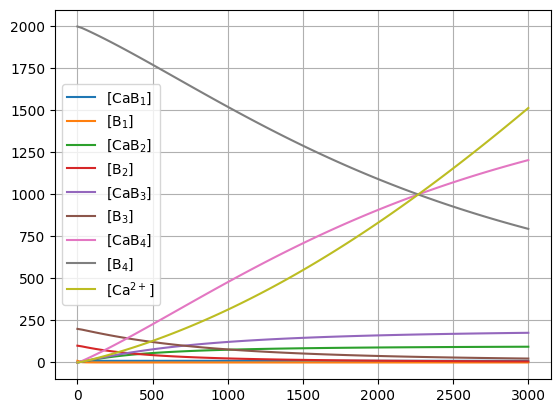

In [67]:
from scipy.optimize import brentq


def equilibrium_criterion(Ca, Ca_0, B_0s, Ks):
    return Ca*(1 + np.sum( B_0s/(Ks + Ca) )) - Ca_0


def calcium_equilibrium(Ca_0,
                        B_0s,
                        Ks):

    B_0s = np.asarray(B_0s, dtype=float)
    Ks = np.asarray(Ks, dtype=float)

    Ca = brentq(equilibrium_criterion, 0.0, Ca_0, args=(Ca_0, B_0s, Ks))

    return Ca


def CaB_equilibrium(Ca_eq, B_0, K):
    return Ca_eq * B_0 / (K + Ca_eq)


Ks = [1, 100, 200, 1000]
B_0s = [10, 100, 200, 2000]
Ca_0s = np.linspace(0, 3000, 100)

CaB_matrix = np.zeros( (len(B_0s), len(Ca_0s)) )
Ca_eqs = np.zeros_like(Ca_0s)

for j, Ca_0 in enumerate(Ca_0s):
    Ca_eqs[j] = calcium_equilibrium(Ca_0, B_0s, Ks)
    for i, (B_0, K) in enumerate(zip(B_0s, Ks)):
        CaB_matrix[i, j] = CaB_equilibrium(Ca_eqs[j], B_0, K)

for i, row in enumerate(CaB_matrix):
    plt.plot(Ca_0s, row, label=fr'[CaB$_{{{i+1}}}$]')
    plt.plot(Ca_0s, B_0s[i]-row, label=fr'[B$_{{{i+1}}}$]')

plt.plot(Ca_0s, Ca_eqs, label=r'[Ca$^{2+}$]')
plt.legend()
plt.grid()
#plt.xscale('log')
plt.show()

In [ ]:
B_0 = 10 #uM
Ca_rest = 50 #nM 
dCa = 100 #nM
K_I = 100 #nM

def CaB(Ca, K_I, B_0):
    return B_0*Ca/(K_I+Ca)

def dCaB(Ca_rest, dCa, K_I, B_0):
    return CaB(Ca_rest+dCa, K_I, B_0) - CaB(Ca_rest, K_I, B_0)

dcab = dCaB(Ca_rest, dCa, K_I, B_0) #uM
print(dcab)

2.6666666666666665


In [138]:
def N_det_spot(P = 2,
               C = 2e-6*N_A,  
               wl = 930e-9,
               Phi = 0.6,
               eta = 0.6,
               eta_NA = 0.4,
               sigma = 50e-58,
               f_p = 80e6,
               tau_p = 100e-15,
               chi = 1,
               xi = 1,
               n = 1.36,
               N_ROI = 50):
    return (np.pi*n*wl*Phi*sigma*xi*chi*eta**2*eta_NA*P**2*C) / (2*h**2*c**2*f_p*tau_p*N_ROI**2)

def N_ROI(dz, rho, A, M):
    return int(rho*dz*A/M**2)

N = N_ROI(15e-3, 1.5e5, 36, 40)
N=50
N_rest = N_det_spot(C=B_0*1e-6*N_A, N_ROI=N)
N_AP = N_det_spot(C=(B_0+dcab)*1e-6*N_A, N_ROI=N)
dt = 1/5143
print(N_rest*dt, N_AP*dt)

5093.735499622919 6452.064966189031


In [139]:
def SNR(N_ph,
        dt = 1/5143,
        QE = 0.45,
        I_dark = 1,
        sigma_read = 22,
        sigma_DS = 40,
        k_PR = 0.018):
    return QE*N_ph*dt / np.sqrt(QE*N_ph*dt+I_dark*dt + sigma_read**2 + sigma_DS**2 + (k_PR*QE**N_ph*dt)**2)

SNR(N_rest/10), SNR(N_AP/10)

(np.float64(4.765852472932395), np.float64(5.958535151960359))

Schmidt coefficients:
[1.61904675e+00 1.01049343e-16 2.95413875e-17 1.92947097e-17
 1.38263825e-17 8.89699521e-18 6.30020854e-18 5.36550436e-18]


C:\Users\geert\AppData\Local\Temp\ipykernel_41020\4283650065.py:103: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y, field, shading='auto')


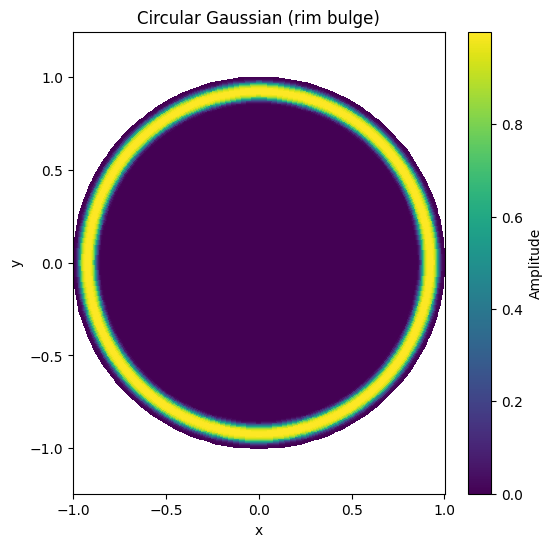

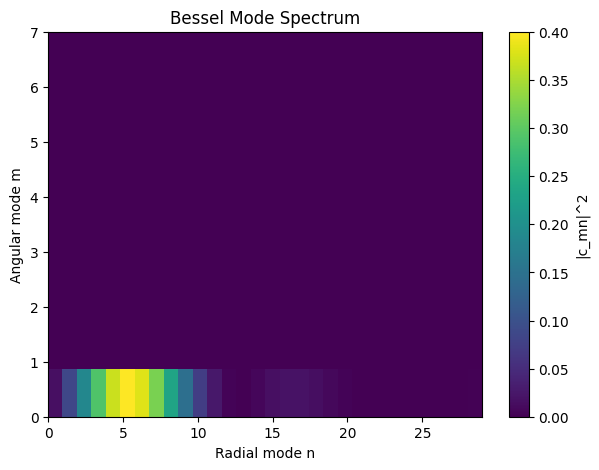

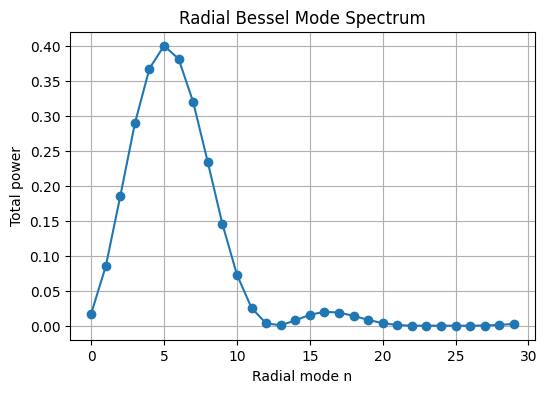

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros
from numpy.linalg import svd

# -----------------------------
# Parameters
# -----------------------------
R = 1
sigma = 0.04

Nr = 200
Ntheta = 200

m_max = 8
n_max = 30

# -----------------------------
# Polar grid
# -----------------------------
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta, endpoint=False)

dr = r[1] - r[0]
dtheta = theta[1] - theta[0]

Rgrid, Tgrid = np.meshgrid(r, theta, indexing='ij')

# Cartesian grid for plotting
X = Rgrid * np.cos(Tgrid)
Y = Rgrid * np.sin(Tgrid)

# -----------------------------
# Circular Gaussian (rim bulge)
# -----------------------------
field = np.exp(-((Rgrid - 0.925*R)**4) / (2 * sigma**4))

# -----------------------------
# Precompute Bessel zeros
# -----------------------------
bessel_zeros = {m: jn_zeros(m, n_max) for m in range(m_max)}

# -----------------------------
# Construct radial Bessel modes
# -----------------------------
radial_modes = {}

for m in range(m_max):

    zeros = bessel_zeros[m]
    modes = []

    for n in range(n_max):

        alpha = zeros[n]
        kr = alpha / R

        mode = jv(m, kr * r)

        # numerical normalization
        norm = np.sqrt(np.sum((mode**2) * r) * dr)
        mode /= norm

        modes.append(mode)

    radial_modes[m] = np.array(modes)

# -----------------------------
# Projection onto Bessel modes
# -----------------------------
coeff = np.zeros((m_max, n_max), dtype=complex)

for m in range(m_max):

    angular_factor = np.exp(-1j * m * theta)

    for n in range(n_max):

        radial_mode = radial_modes[m][n][:, None]

        basis = radial_mode * angular_factor

        integrand = field * np.conj(basis) * Rgrid

        coeff[m, n] = np.sum(integrand) * dr * dtheta

# Bessel power spectrum
spectrum = np.abs(coeff)**2

# -----------------------------
# Schmidt decomposition
# -----------------------------
U, S, Vh = svd(coeff)

print("Schmidt coefficients:")
print(S)

# -----------------------------
# Plot initial distribution
# -----------------------------
plt.figure(figsize=(6,6))

plt.pcolormesh(X, Y, field, shading='auto')
plt.colorbar(label="Amplitude")

plt.title("Circular Gaussian (rim bulge)")
plt.xlabel("x")
plt.ylabel("y")

plt.axis("equal")

plt.show()

# -----------------------------
# Plot Bessel spectrum heatmap
# -----------------------------
plt.figure(figsize=(7,5))

plt.imshow(
    spectrum,
    origin="lower",
    aspect="auto",
    extent=[0, n_max-1, 0, m_max-1]
)

plt.colorbar(label="|c_mn|^2")

plt.xlabel("Radial mode n")
plt.ylabel("Angular mode m")

plt.title("Bessel Mode Spectrum")

plt.show()

# -----------------------------
# Radially summed spectrum
# -----------------------------
radial_spectrum = np.sum(spectrum, axis=0)

plt.figure(figsize=(6,4))

plt.plot(radial_spectrum, marker='o')

plt.xlabel("Radial mode n")
plt.ylabel("Total power")

plt.title("Radial Bessel Mode Spectrum")

plt.grid()

plt.show()

In [ ]:
# -----------------------------
# Reconstruction
# -----------------------------
f_rec = np.zeros_like(r)

for n in range(n_modes):

    alpha = zeros[n]
    kr = alpha / R

    mode = jv(0, kr * r)

    norm = np.sqrt(np.sum(mode**2 * r) * dr)
    mode /= norm

    f_rec += coeff[n] * mode

# -----------------------------
# Plot radial profiles
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(r, f, label="Original Gaussian rim", linewidth=3)
plt.plot(r, f_rec, "--", label="Bessel reconstruction", linewidth=2)

plt.xlabel("Radius r")
plt.ylabel("Amplitude")
plt.title("Gaussian Rim vs Bessel Reconstruction")

plt.legend()
plt.grid()

plt.show()

NameError: name 'f' is not defined

<Figure size 700x500 with 0 Axes>

[  2.40482556   5.52007811   8.65372791  11.79153444  14.93091771
  18.07106397  21.21163663  24.35247153  27.49347913  30.63460647
  33.77582021  36.91709835  40.05842576  43.19979171  46.34118837
  49.4826099   52.62405184  55.76551076  58.90698393  62.04846919
  65.1899648   68.33146933  71.4729816   74.61450064  77.75602563
  80.89755587  84.03909078  87.18062984  90.32217264  93.46371878
  96.60526795  99.74681986 102.88837425 106.02993092 109.17148965
 112.31305028 115.45461265 118.59617663 121.73774209 124.87930891
 128.02087701 131.16244628 134.30401664 137.44558802 140.58716035
 143.72873357 146.87030763 150.01188246 153.15345802 156.29503427
 159.43661116 162.57818867 165.71976675 168.86134537 172.0029245
 175.14450412 178.2860842  181.42766471 184.56924564 187.71082696
 190.85240865 193.9939907  197.13557309 200.27715579 203.41873881
 206.56032212 209.7019057  212.84348956 215.98507367 219.12665803
 222.26824262 225.40982743 228.55141247 231.6929977  234.83458314
 237.976168

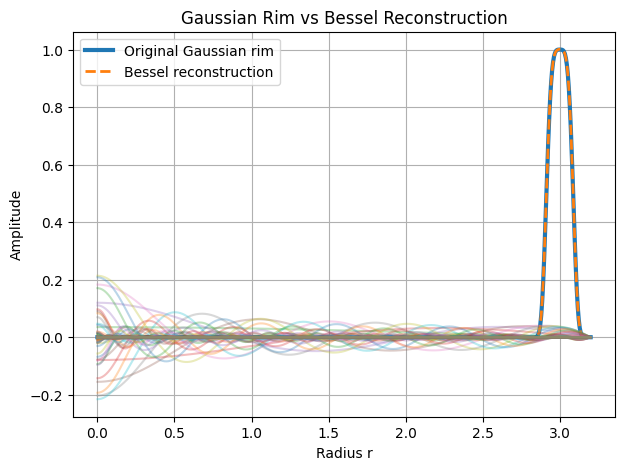

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros

# -----------------------------
# Parameters
# -----------------------------
R = 3.2
sigma = 0.08

Nr = 500
n_modes = 100

# -----------------------------
# Radial grid
# -----------------------------
r = np.linspace(0, R, Nr)
dr = r[1] - r[0]

# Circular Gaussian rim profile
f = np.exp(-((r - 3)**4) / (2 * sigma**4))

# -----------------------------
# Bessel zeros
# -----------------------------
zeros = jn_zeros(0, n_modes)

# -----------------------------
# Compute coefficients
# -----------------------------
coeff = np.zeros(n_modes)

for n in range(n_modes):

    alpha = zeros[n]
    kr = alpha / R

    mode = jv(0, kr * r)

    # normalization
    norm = np.sqrt(np.sum(mode**2 * r) * dr)
    mode /= norm

    coeff[n] = np.sum(f * mode * r) * dr

# -----------------------------
# Reconstruction
# -----------------------------
f_rec = np.zeros_like(r)

for n in range(n_modes):

    alpha = zeros[n]
    kr = alpha / R

    mode = jv(0, kr * r)

    norm = np.sqrt(np.sum(mode**2 * r) * dr)
    mode /= norm

    f_rec += coeff[n] * mode

# -----------------------------
# Plot radial profiles
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(r, f, label="Original Gaussian rim", linewidth=3)
plt.plot(r, f_rec, "--", label="Bessel reconstruction", linewidth=2)
print(zeros, coeff)
for n in range(n_modes):
    plt.plot(r, coeff[n]*jv(0, zeros[n]/R * r), alpha=.3)

plt.xlabel("Radius r")
plt.ylabel("Amplitude")
plt.title("Gaussian Rim vs Bessel Reconstruction")

plt.legend()
plt.grid()

plt.show()

C:\Users\geert\AppData\Local\Temp\ipykernel_41020\1049758816.py:84: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax_disk.pcolormesh(


Saved: bessel_modes_evolution.gif


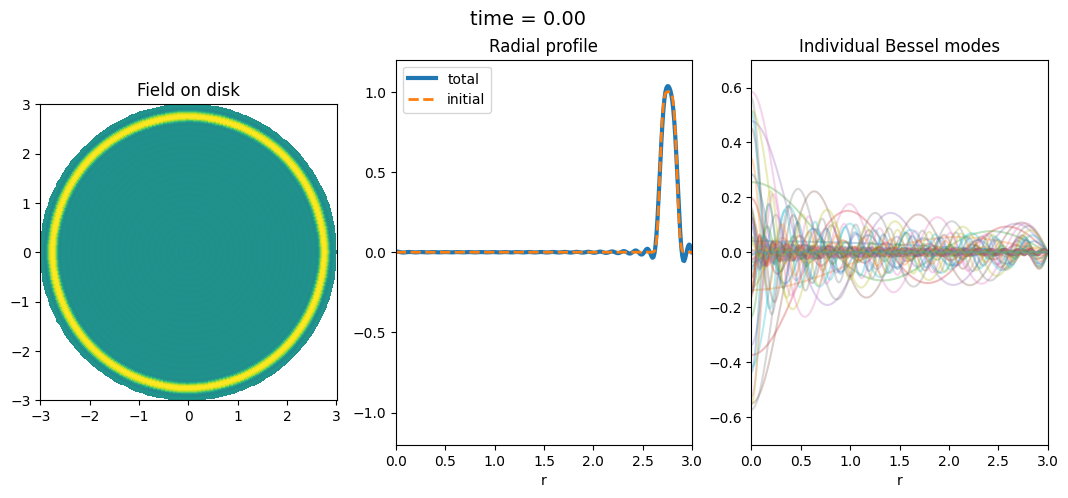

In [143]:
from scipy.special import jv, jn_zeros
from matplotlib.animation import FuncAnimation, PillowWriter

# -----------------------------
# Parameters
# -----------------------------
R = 3.0
sigma = 0.08

Nr = 300
Ntheta = 220

n_modes = 50

fps = 15            # slower playback
duration = 20       # longer animation
frames = fps * duration

# -----------------------------
# Frequency dispersion
# -----------------------------
def omega(n):
    return jn_zeros(0, n_modes)[n]


# -----------------------------
# Grid
# -----------------------------
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)

Rgrid, Tgrid = np.meshgrid(r, theta, indexing="ij")

X = Rgrid * np.cos(Tgrid)
Y = Rgrid * np.sin(Tgrid)

dr = r[1] - r[0]

# -----------------------------
# Initial radial Gaussian
# -----------------------------
f = np.exp(-((r - .92*R)**4)/(2*sigma**4))

# -----------------------------
# Bessel basis
# -----------------------------
zeros = jn_zeros(0, n_modes)

coeff = np.zeros(n_modes)
radial_modes = []

for n in range(n_modes):

    alpha = zeros[n]
    kr = alpha / R

    mode = jv(0, kr*r)

    norm = np.sqrt(np.sum(mode**2 * r) * dr)
    mode /= norm

    radial_modes.append(mode)

    coeff[n] = np.sum(f * mode * r) * dr

radial_modes = np.array(radial_modes)

# Precompute max possible amplitude for axis scaling
mode_amplitudes = np.abs(coeff[:,None] * radial_modes)
mode_max = np.max(mode_amplitudes)

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(13,5))

ax_disk = fig.add_subplot(131)
ax_radial = fig.add_subplot(132)
ax_modes = fig.add_subplot(133)

# disk field
field = np.zeros_like(Rgrid)

im = ax_disk.pcolormesh(
    X, Y, field,
    shading="auto",
    cmap="viridis",
    vmin=-np.max(np.abs(f)),
    vmax=np.max(np.abs(f))
)

ax_disk.set_aspect("equal")
ax_disk.set_title("Field on disk")

# radial profile
line_total, = ax_radial.plot([], [], lw=3, label="total")
line_initial, = ax_radial.plot(r, f, "--", lw=2, label="initial")

ax_radial.set_xlim(0, R)
ax_radial.set_ylim(-1.2*np.max(f), 1.2*np.max(f))

ax_radial.set_xlabel("r")
ax_radial.set_title("Radial profile")
ax_radial.legend()

# individual modes
mode_lines = []
for n in range(n_modes):
    line, = ax_modes.plot([], [], alpha=0.3)
    mode_lines.append(line)

ax_modes.set_xlim(0, R)
ax_modes.set_ylim(-1.2*mode_max, 1.2*mode_max)
ax_modes.set_xlabel("r")
ax_modes.set_title("Individual Bessel modes")

# timestamp
time_text = fig.suptitle("", fontsize=14)

# -----------------------------
# Animation update
# -----------------------------
def update(frame):

    t = frame / fps

    radial_total = np.zeros_like(r)
    components = []

    for n in range(n_modes):

        comp = coeff[n] * radial_modes[n] * np.cos(omega(n)*t)

        radial_total += comp
        components.append(comp)

    # update 2D field
    field = radial_total[:,None] * np.ones((1, Ntheta))
    im.set_array(field.ravel())

    # radial profile
    line_total.set_data(r, radial_total)

    # mode components
    for n,line in enumerate(mode_lines):
        line.set_data(r, components[n])

    time_text.set_text(f"time = {t:0.2f}")

    return [im, line_total, *mode_lines]


# -----------------------------
# Create animation
# -----------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=1000/fps
)

anim.save("bessel_modes_evolution.gif", writer=PillowWriter(fps=fps))

print("Saved: bessel_modes_evolution.gif")

C:\Users\geert\AppData\Local\Temp\ipykernel_41020\2987985286.py:75: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax_disk.pcolormesh(


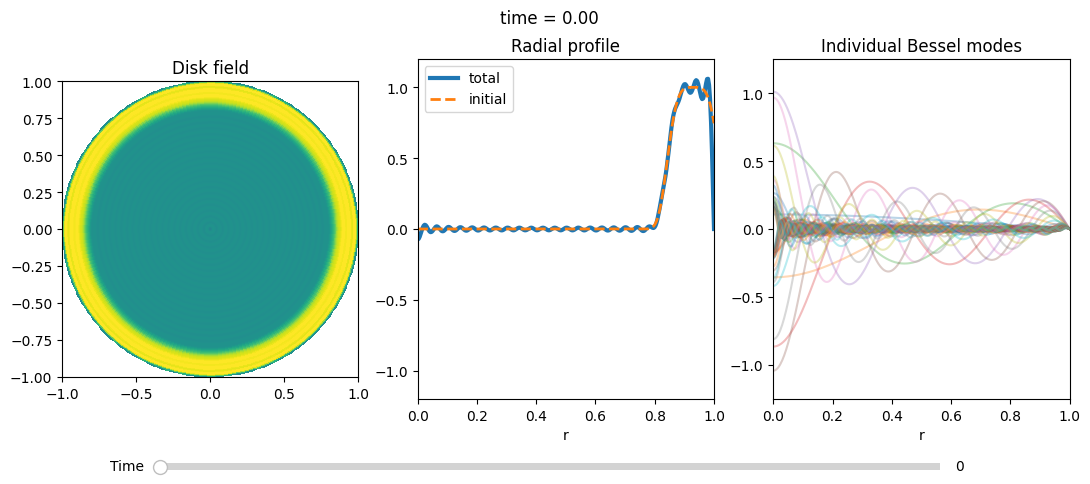

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros
from matplotlib.widgets import Slider

# -----------------------------
# Parameters
# -----------------------------
R = 1.0
sigma = 0.08

Nr = 300
Ntheta = 220

n_modes = 50

T_max = 20  # maximum time to sweep
c3 = 1.0    # arbitrary third-sound speed for example

# -----------------------------
# Frequency dispersion (linear)
# -----------------------------
zeros = jn_zeros(0, n_modes)

def omega(n):
    k = zeros[n]/R
    return c3 * k

# -----------------------------
# Grid
# -----------------------------
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)

Rgrid, Tgrid = np.meshgrid(r, theta, indexing="ij")
X = Rgrid * np.cos(Tgrid)
Y = Rgrid * np.sin(Tgrid)

dr = r[1] - r[0]

# -----------------------------
# Initial radial Gaussian rim
# -----------------------------
f = np.exp(-((r-0.93*R)**4)/(2*sigma**4))

# -----------------------------
# Bessel basis
# -----------------------------
coeff = np.zeros(n_modes)
radial_modes = []

for n in range(n_modes):
    kr = zeros[n]/R
    mode = jv(0, kr*r)
    norm = np.sqrt(np.sum(mode**2 * r) * dr)
    mode /= norm
    radial_modes.append(mode)
    coeff[n] = np.sum(f * mode * r) * dr

radial_modes = np.array(radial_modes)
mode_max = np.max(np.abs(coeff[:,None]*radial_modes))

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(13,5))
plt.subplots_adjust(bottom=0.2)

ax_disk = fig.add_subplot(131)
ax_radial = fig.add_subplot(132)
ax_modes = fig.add_subplot(133)

# 2D disk field
field = np.zeros_like(Rgrid)
im = ax_disk.pcolormesh(
    X, Y, field, shading="auto", cmap="viridis",
    vmin=-np.max(np.abs(f)), vmax=np.max(np.abs(f))
)
ax_disk.set_aspect("equal")
ax_disk.set_title("Disk field")

# radial profile
line_total, = ax_radial.plot([], [], lw=3, label="total")
line_initial, = ax_radial.plot(r, f, "--", lw=2, label="initial")
ax_radial.set_xlim(0, R)
ax_radial.set_ylim(-1.2*np.max(f), 1.2*np.max(f))
ax_radial.set_xlabel("r")
ax_radial.set_title("Radial profile")
ax_radial.legend()

# individual modes
mode_lines = []
for n in range(n_modes):
    line, = ax_modes.plot([], [], alpha=0.3)
    mode_lines.append(line)
ax_modes.set_xlim(0, R)
ax_modes.set_ylim(-1.2*mode_max, 1.2*mode_max)
ax_modes.set_xlabel("r")
ax_modes.set_title("Individual Bessel modes")

# timestamp
time_text = fig.suptitle("")

# -----------------------------
# Update function
# -----------------------------
def update(t):
    radial_total = np.zeros_like(r)
    components = []
    for n in range(n_modes):
        comp = coeff[n]*radial_modes[n]*np.cos(omega(n)*t)
        radial_total += comp
        components.append(comp)

    # update 2D field
    field = radial_total[:,None]*np.ones((1, Ntheta))
    im.set_array(field.ravel())

    # radial profile
    line_total.set_data(r, radial_total)

    # individual modes
    for n, line in enumerate(mode_lines):
        line.set_data(r, components[n])

    time_text.set_text(f"time = {t:.2f}")

    fig.canvas.draw_idle()

# -----------------------------
# Slider setup
# -----------------------------
ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03], facecolor='lightgray')
slider = Slider(ax_slider, 'Time', 0.0, T_max, valinit=0.0)

def slider_update(val):
    update(slider.val)

slider.on_changed(slider_update)

# Initial draw
update(0.0)
plt.show()